# Kapitel 2: Die Daten bereinigen

## Bisher...

In Kapitel 1 haben wir 400.000 Amazon-Bewertungen entdeckt — perfekt balanciert,
mit minimalem Datenverlust. Doch Rohdaten sind wie ungefilterte Gedanken:
Sie enthalten Rauschen, das unsere Maschine verwirren würde.

## Was passiert in diesem Kapitel?

Wir bringen Ordnung in die Daten:
1. Fehlende Werte und Duplikate entfernen
2. Ein klares Sentiment-Label erstellen (0 = negativ, 1 = positiv)
3. Den Text normalisieren — damit *"GREAT!!!"* und *"great"* als dasselbe Wort erkannt werden
4. Die bereinigten Daten als Parquet speichern

## 2.1 Daten laden

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonReviews – Datenbereinigung") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

df_raw = spark.read.csv(
    "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/data/test.csv",
    header=False, inferSchema=True, multiLine=True, escape='"'
)
df_raw = df_raw.toDF("Score", "Summary", "Text")

print(f"Rohdaten geladen: {df_raw.count():,} Zeilen")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/20 16:47:00 WARN Utils: Your hostname, Alper-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.3 instead (on interface en0)
26/03/20 16:47:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/20 16:47:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/20 16:47:01 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Rohdaten geladen: 400,000 Zeilen


## 2.2 Fehlende Werte entfernen

Aus Kapitel 1 wissen wir: Nur 4 Zeilen haben fehlende Summary-Werte.
Wir entfernen sie — der Verlust ist vernachlässigbar.

In [2]:
before = df_raw.count()
df_no_nulls = df_raw.dropna()
after = df_no_nulls.count()

print(f"Vorher:  {before:,}")
print(f"Nachher: {after:,}")
print(f"Entfernt: {before - after:,} Zeilen")

Vorher:  400,000
Nachher: 399,996
Entfernt: 4 Zeilen


## 2.3 Duplikate entfernen

In [3]:
before = df_no_nulls.count()
df_no_dups = df_no_nulls.dropDuplicates()
after = df_no_dups.count()

print(f"Vorher:  {before:,}")
print(f"Nachher: {after:,}")
print(f"Duplikate entfernt: {before - after:,} Zeilen")

Vorher:  399,996
Nachher: 399,996
Duplikate entfernt: 0 Zeilen


## 2.4 Sentiment-Label erstellen

Der Original-Score verwendet 1 und 2. Für Machine Learning ist ein
Standard-Label besser verständlich:

- **Score 1 → Label 0** (negativ)
- **Score 2 → Label 1** (positiv)

Warum? Weil 0/1 die Standardkonvention in der binären Klassifikation ist
und die meisten ML-Algorithmen darauf ausgelegt sind.

In [4]:
from pyspark.sql.functions import when, col

df_labeled = df_no_dups.withColumn(
    "label",
    when(col("Score") == 1, 0).otherwise(1)
)

df_labeled.groupBy("label").count().orderBy("label").show()

+-----+------+
|label| count|
+-----+------+
|    0|199998|
|    1|199998|
+-----+------+



## 2.5 Text normalisieren — Der wichtigste Schritt

Für eine Maschine sind *"Great"*, *"GREAT"*, *"great!!!"* und *"great."*
vier verschiedene Wörter. Wir müssen sie vereinheitlichen:

1. **Kleinschreibung** — *GREAT* → *great*
2. **HTML-Tags entfernen** — `<br />` und `<p>` aus dem Text löschen
3. **Sonderzeichen entfernen** — Nur Buchstaben und Leerzeichen behalten
4. **Mehrfache Leerzeichen** — Zusammenfassen

Das Ziel: Ein sauberer, einheitlicher Text, den die Tokenisierung im nächsten Schritt
sauber in Wörter zerlegen kann.

In [5]:
from pyspark.sql.functions import lower, regexp_replace, trim, length

df_clean = df_labeled \
    .withColumn("clean_text", lower(col("Text"))) \
    .withColumn("clean_text", regexp_replace("clean_text", "<[^>]*>", " ")) \
    .withColumn("clean_text", regexp_replace("clean_text", "[^a-z\\s]", " ")) \
    .withColumn("clean_text", regexp_replace("clean_text", "\\s+", " ")) \
    .withColumn("clean_text", trim(col("clean_text")))

df_clean = df_clean \
    .withColumn("clean_summary", lower(col("Summary"))) \
    .withColumn("clean_summary", regexp_replace("clean_summary", "<[^>]*>", " ")) \
    .withColumn("clean_summary", regexp_replace("clean_summary", "[^a-z\\s]", " ")) \
    .withColumn("clean_summary", regexp_replace("clean_summary", "\\s+", " ")) \
    .withColumn("clean_summary", trim(col("clean_summary")))

print("Textnormalisierung abgeschlossen.")
df_clean.select("Text", "clean_text").show(3, truncate=80)

Textnormalisierung abgeschlossen.


+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            Text|                                                                      clean_text|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|I was so disappointed in the first book, Foundation, I gave it two stars. I'v...|i was so disappointed in the first book foundation i gave it two stars i ve b...|
|The book details many or most of the important dynamics of the war as it took...|the book details many or most of the important dynamics of the war as it took...|
|Bought this for my Grandson to sleep on when the family came to visit over Ch...|bought this for my grandson to sleep on when the family came to visit over ch...|
+---------------

## 2.6 Leere Texte entfernen

In [6]:
before = df_clean.count()
df_clean = df_clean.filter(length(col("clean_text")) >= 3)
after = df_clean.count()

print(f"Vorher:  {before:,}")
print(f"Nachher: {after:,}")
print(f"Leere/kurze Texte entfernt: {before - after:,}")

Vorher:  399,996
Nachher: 399,995
Leere/kurze Texte entfernt: 1


## 2.7 Finale Spaltenauswahl

In [7]:
df_final = df_clean.select(
    col("label"),
    col("clean_summary").alias("summary"),
    col("clean_text").alias("text")
)

print(f"Finale Spalten: {df_final.columns}")
print(f"Zeilenanzahl:   {df_final.count():,}")
df_final.show(5, truncate=80)

Finale Spalten: ['label', 'summary', 'text']


Zeilenanzahl:   399,995


+-----+-----------------------------------------+--------------------------------------------------------------------------------+
|label|                                  summary|                                                                            text|
+-----+-----------------------------------------+--------------------------------------------------------------------------------+
|    1|heads above the first book in the trilogy|i was so disappointed in the first book foundation i gave it two stars i ve b...|
|    1| persuasive book with an unusual approach|the book details many or most of the important dynamics of the war as it took...|
|    1|                     great bed for guests|bought this for my grandson to sleep on when the family came to visit over ch...|
|    1|                             good printer|i have bought this printer for my personal use at home it is good and reliabl...|
|    1|                      took my breath away|ok maybe i m exaggerating just a l

## 2.8 Ist die Balance erhalten geblieben?

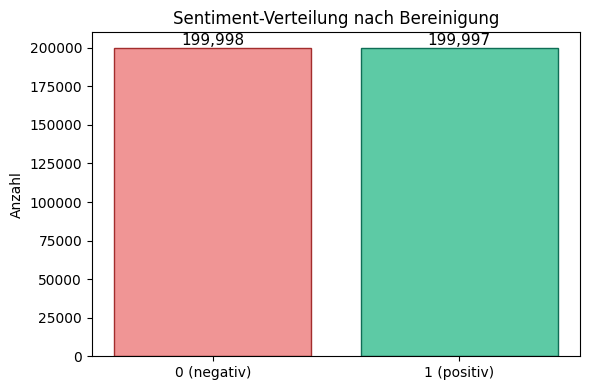

In [8]:
import matplotlib.pyplot as plt

label_dist = df_final.groupBy("label").count().orderBy("label").toPandas()

plt.figure(figsize=(6, 4))
colors = ["#F09595", "#5DCAA5"]
bars = plt.bar(
    ["0 (negativ)", "1 (positiv)"],
    label_dist["count"],
    color=colors, edgecolor=["#A32D2D", "#0F6E56"]
)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=11)

plt.ylabel("Anzahl")
plt.title("Sentiment-Verteilung nach Bereinigung")
plt.tight_layout()
plt.show()

### Erkenntnis

Die Balance ist nahezu perfekt erhalten geblieben. Die wenigen entfernten Zeilen
haben das Verhältnis nicht beeinflusst.

## 2.9 Textlängen nach Bereinigung

In [9]:
from pyspark.sql.functions import avg, min as spark_min, max as spark_max, round as spark_round

df_final.withColumn("text_length", length(col("text"))) \
    .select(
        spark_min("text_length").alias("Min"),
        spark_round(avg("text_length"), 0).alias("Durchschnitt"),
        spark_max("text_length").alias("Max")
    ).show()

+---+------------+---+
|Min|Durchschnitt|Max|
+---+------------+---+
| 14|       393.0|991|
+---+------------+---+



## 2.10 Als Parquet speichern

Wir speichern die bereinigten Daten im **Parquet-Format**. Warum nicht als CSV?

- **Komprimierung**: Parquet spart ~80% Speicher gegenüber CSV
- **Schema**: Datentypen werden mitgespeichert — kein `inferSchema` mehr nötig
- **Geschwindigkeit**: Spark liest Parquet deutlich schneller als CSV
- **Standard**: Parquet ist das Standardformat in der Big-Data-Welt

In [10]:
output_path = "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/cleaned_reviews.parquet"
df_final.write.parquet(output_path, mode="overwrite")
print(f"Bereinigte Daten gespeichert unter: {output_path}")

Bereinigte Daten gespeichert unter: /Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/cleaned_reviews.parquet


In [11]:
df_check = spark.read.parquet(output_path)
print(f"Parquet gelesen: {df_check.count():,} Zeilen")
df_check.show(3, truncate=80)

Parquet gelesen: 399,995 Zeilen
+-----+---------------------------------+--------------------------------------------------------------------------------+
|label|                          summary|                                                                            text|
+-----+---------------------------------+--------------------------------------------------------------------------------+
|    1|       good follow up to el cielo|a bit of a change this time for dredg less progressive material more straight...|
|    1|                  love this movie|great movie but no special features on it once i opened that movie i noticed ...|
|    0|is loosing air with almost no use|i bought this airbed on october i only used it times and now is loosing air h...|
+-----+---------------------------------+--------------------------------------------------------------------------------+
only showing top 3 rows


## Kapitel 2 — Zusammenfassung

| Schritt | Beschreibung | Entfernte Zeilen |
|---------|-------------|------------------|
| Null-Werte | `dropna()` | 4 |
| Duplikate | `dropDuplicates()` | 0 |
| Normalisierung | lowercase, regex, trim | — |
| Leere Texte | Textlänge < 3 Zeichen | ~1 |
| Label | Score 1→0, Score 2→1 | — |

**Ergebnis:** Von 400.000 Zeilen bleiben ~399.995 übrig — ein Verlust von nur 0,001%.
Die Daten sind jetzt sauber, normalisiert und bereit für die NLP-Verarbeitung.

**Nächstes Kapitel:** Wir verwandeln Wörter in Zahlen — mit Tokenisierung und TF-IDF.
Denn eine Maschine kann keine Wörter lesen, nur Vektoren.